In [1]:
from FormUtils import pyForm, capture_physics_expr

In [2]:
%%pyForm ee_inclZ_mumu

* Process: e+ e- -> mu+ mu- (EW)

#-
* Above suppresses extra output
Off Statistics;
Off FinalStats;

#include FeynHelpers.h

* Physical constants
Symbols e, pi, alpha, mZ, gweak, x;


Local MQED = (e^2 )    * (VB(i1, p2, 0) * g(i1, i2, mu1) * U(i2, p1, 0))  
                       * phprop(mu1, mu2, q) 
                       * (UB(i3, p3, 0) * g(i3, i4, mu2) * V(i4, p4, 0));

Local MZ = (gweak^2/4) * (VB(i1, p2, 0) * g(i1, i2, mu1) 
                       * 1/2* ((cv-ca)*g(i2, i3, k7) + (cv+ca)*g(i2, i3, k6)) 
                       * U(i3, p1, 0))
                       * Zprop(mu1, mu2, q, mZ)
                       * (UB(i4, p3, 0) * g(i4, i5, mu2) 
                       * 1/2 * ((cv-ca)*g(i5, i6, k7) + (cv+ca)*g(i5, i6, k6)) 
                       * V(i6, p4, 0));
Local Mtot = MQED + MZ;

#call squareamplitude(MQED, MsqQED)
#call squareamplitude(MZ, MsqZ)
#call squareamplitude(Mtot, MsqTot)
.sort 
Local MsqInt = MsqTot - MsqQED - MsqZ;
.sort


* Spin averaging (1/2 * 1/2)
multiply 1/4; 
* coupling
id e^4 = 16 * pi^2 * alpha^2;
id e^2 = 4 * pi * alpha;
* propagator handling
id prop(x?) = (x)^-1;
id (q.q)^-1 = (s)^-1;
id (-mZ^2 + q.q)^-1 = (s - mZ^2)^-1;
repeat;
    id q = p1 + p2;
endrepeat;
.sort

* Kinematics 
#call Mandelstam2To2(p1,p2,p3,p4,0,0,0,0)


Bracket s, alpha, gweak;
.sort
* Save
Format C;
#write <ee_incl_mumu_QED.txt> "%e;", MsqQED;
#write <ee_incl_mumu_Int.txt> "%e;", MsqInt;
#write <ee_incl_mumu_Z.txt> "%e;", MsqZ;
.sort

* Print
Format;
Print +s MsqZ;
Print +s MsqInt;
Print +s MsqQED;
.end

FORM 5.0.0 (Jan 27 2026, v5.0.0)                 Run: Sat Apr 18 04:36:49 2026
    
    * Process: e+ e- -> mu+ mu- (EW)
    
    #-

   MsqQED =
       + 32*s^(-2)*u^2*pi^2*alpha^2
       + 32*s^(-2)*t^2*pi^2*alpha^2
      ;

   MsqZ =
       + 1/8/( - mZ^2 + s)/( - mZ^2 + s)*u^2*ca^4*gweak^4
       + 3/4/( - mZ^2 + s)/( - mZ^2 + s)*u^2*cv^2*ca^2*gweak^4
       + 1/8/( - mZ^2 + s)/( - mZ^2 + s)*u^2*cv^4*gweak^4
       + 1/8/( - mZ^2 + s)/( - mZ^2 + s)*t^2*ca^4*gweak^4
       - 1/4/( - mZ^2 + s)/( - mZ^2 + s)*t^2*cv^2*ca^2*gweak^4
       + 1/8/( - mZ^2 + s)/( - mZ^2 + s)*t^2*cv^4*gweak^4
      ;

   MsqInt =
       + 4/( - mZ^2 + s)*s^(-1)*u^2*ca^2*pi*alpha*gweak^2
       + 4/( - mZ^2 + s)*s^(-1)*u^2*cv^2*pi*alpha*gweak^2
       - 4/( - mZ^2 + s)*s^(-1)*t^2*ca^2*pi*alpha*gweak^2
       + 4/( - mZ^2 + s)*s^(-1)*t^2*cv^2*pi*alpha*gweak^2
      ;




MsqQED :
    2  2 ⎛ 2    2⎞
32⋅π ⋅α ⋅⎝t  + u ⎠
──────────────────
         2        
        s         


MsqZ :
     4 ⎛        4  2           4  2          2   2  2          2   2  2        ↪
gweak ⋅⎝0.125⋅ca ⋅t  + 0.125⋅ca ⋅u  - 0.25⋅ca ⋅cv ⋅t  + 0.75⋅ca ⋅cv ⋅u  + 0.12 ↪
────────────────────────────────────────────────────────────────────────────── ↪
                                                       2                       ↪
                                              ⎛  2    ⎞                        ↪
                                              ⎝mZ  - s⎠                        ↪

↪     4  2           4  2⎞
↪ 5⋅cv ⋅t  + 0.125⋅cv ⋅u ⎠
↪ ────────────────────────
↪                         
↪                         
↪                         


MInt :
           2 ⎛    2  2     2  2     2  2     2  2⎞
4⋅π⋅α⋅gweak ⋅⎝- ca ⋅t  + ca ⋅u  + cv ⋅t  + cv ⋅u ⎠
──────────────────────────────────────────────────
                    ⎛    2    ⎞                   
                  s⋅⎝- mZ

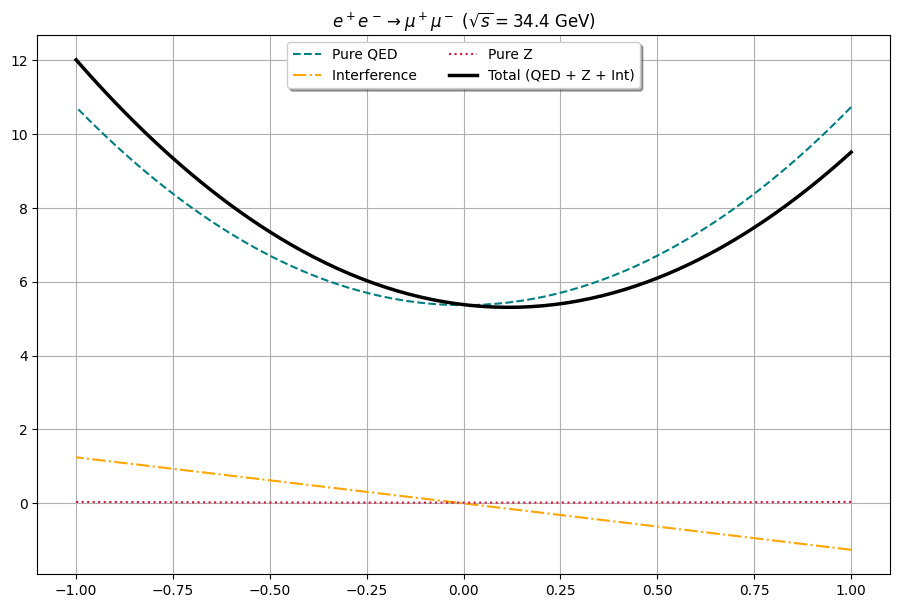

In [3]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from Kinematics import XS_2To2_CM

plt.style.use("seaborn-v0_8-muted")
plt.rcParams["axes.grid"] = True


# Capture from FORM
form_exprQED = capture_physics_expr("scripts/ee_incl_mumu_QED.txt")
form_exprZ = capture_physics_expr("scripts/ee_incl_mumu_Z.txt")
form_exprInt = capture_physics_expr("scripts/ee_incl_mumu_Int.txt")

# Simplify via sympy
alpha, gweak, mZ, s = sp.symbols("alpha gweak mZ s")
cv, ca, t, u = sp.symbols("cv ca t u")
MsqQED = sp.simplify(form_exprQED)
print(f"MsqQED :")
sp.pprint(MsqQED,num_columns=80)
print("\n")

MsqZ = sp.simplify(form_exprZ)
print(f"MsqZ :")
sp.pprint(MsqZ,num_columns=80)
print("\n")


MInt = sp.simplify(form_exprInt)
print(f"MInt :")
sp.pprint(MInt,num_columns=80)
print("\n")

# Get the xs in CM
theta = sp.Symbol("theta", real=True)

xsQED = XS_2To2_CM(MsqQED, s, t, u, theta, 0, 0, 0, 0)
print(f"xsQED :")
sp.pprint(xsQED,num_columns=80)
print("\n")

xsZ = XS_2To2_CM(MsqZ, s, t, u, theta, 0, 0, 0, 0)
print(f"xsZ :")
sp.pprint(xsZ,num_columns=80)
print("\n")

xsInt = XS_2To2_CM(MInt, s, t, u, theta, 0, 0, 0, 0)
print(f"xsInt :")
sp.pprint(xsInt,num_columns=80)
print("\n")

# lambdify
xsQED_lambda = sp.lambdify((s, alpha, theta), xsQED, "numpy")
xsZ_lambda = sp.lambdify((s, gweak, cv, ca, mZ, theta), xsZ, "numpy")
xsInt_lambda = sp.lambdify((s, alpha, gweak, cv, ca, mZ, theta), xsInt, "numpy")

#
sqrtS = 34.4
s_val = sqrtS * sqrtS
# Running of alpha
alpha_val = (1 / 137.036) / (
    1 - (1 / (137.036 * 3 * np.pi)) * np.log(s_val / 5.11e-4**2)
)
# Weak coupling
sin2w = 0.23122
gweak_val = np.sqrt(4 * np.pi * alpha_val) / np.sqrt(sin2w * (1 - sin2w))
#
mZ_val = 91.1876
cv_val = -0.5 + 2 * sin2w
ca_val = -0.5
#
conv_gev2_to_nb = 389379.0

# Fill values for Plotting
angles = np.linspace(0, np.pi, 100)
x_vals = np.cos(angles)


y_QED = xsQED_lambda(s_val, alpha_val, angles)
y_QED = s_val * y_QED * conv_gev2_to_nb

y_Z = xsZ_lambda(s_val, gweak_val, cv_val, ca_val, mZ_val, angles)
y_Z = (sqrtS**2) * y_Z * conv_gev2_to_nb

y_Int = xsInt_lambda(s_val, alpha_val, gweak_val, cv_val, ca_val, mZ_val, angles)
y_Int = (sqrtS**2) * y_Int * conv_gev2_to_nb

y_Total = y_QED + y_Z + y_Int

plt.figure(figsize=(11, 7))
plt.title(rf"$e^+e^- \to \mu^+\mu^-$ ($\sqrt{{s}}={(sqrtS)}$ GeV)")
plt.plot(x_vals, y_QED, label="Pure QED ", color="teal", lw=1.5, ls="--")
plt.plot(x_vals, y_Int, label="Interference ", color="orange", lw=1.5, ls="-.")
plt.plot(x_vals, y_Z, label="Pure Z ", color="crimson", lw=1.5, ls=":")
plt.plot(x_vals, y_Total, label="Total (QED + Z + Int)", color="black", lw=2.5)
plt.legend(loc="upper center", ncol=2, frameon=True, shadow=True, fontsize=10)
plt.show()